In [59]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv('GHI Final Dataset.csv', encoding='ISO-8859-1')

# Preprocess the dataset
df['GHI_Label'] = (df['Hunger_Index'] // 10).astype(int) # Divide Hunger_Index by 10 to create discrete labels (1 to 10)
df['GHI_Label'] = df['GHI_Label'].clip(1, 10)  # values are between 1 and 10
print(df['GHI_Label'])

0        4
1        4
2        4
3        4
4        4
        ..
36895    2
36896    2
36897    2
36898    2
36899    2
Name: GHI_Label, Length: 36900, dtype: int64


In [60]:
# Feature selection
X = df[['Population_Growth', 'Annual_Precipitation_mm', 'IDP_Count']]
y = df['GHI_Label'] 

In [61]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
# Train the decision tree model
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [63]:
# Make predictions
y_pred = clf.predict(X_test)

#  Create and train the decision tree model
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

In [64]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print(classification_report(y_test, y_pred))

Accuracy: 0.75
              precision    recall  f1-score   support

           1       0.78      0.96      0.86      4111
           2       0.63      0.48      0.55      1508
           3       0.71      0.49      0.58      1135
           4       0.79      0.34      0.47       488
           5       0.79      0.63      0.70       103
           6       0.80      0.91      0.85        35

    accuracy                           0.75      7380
   macro avg       0.75      0.64      0.67      7380
weighted avg       0.74      0.75      0.73      7380



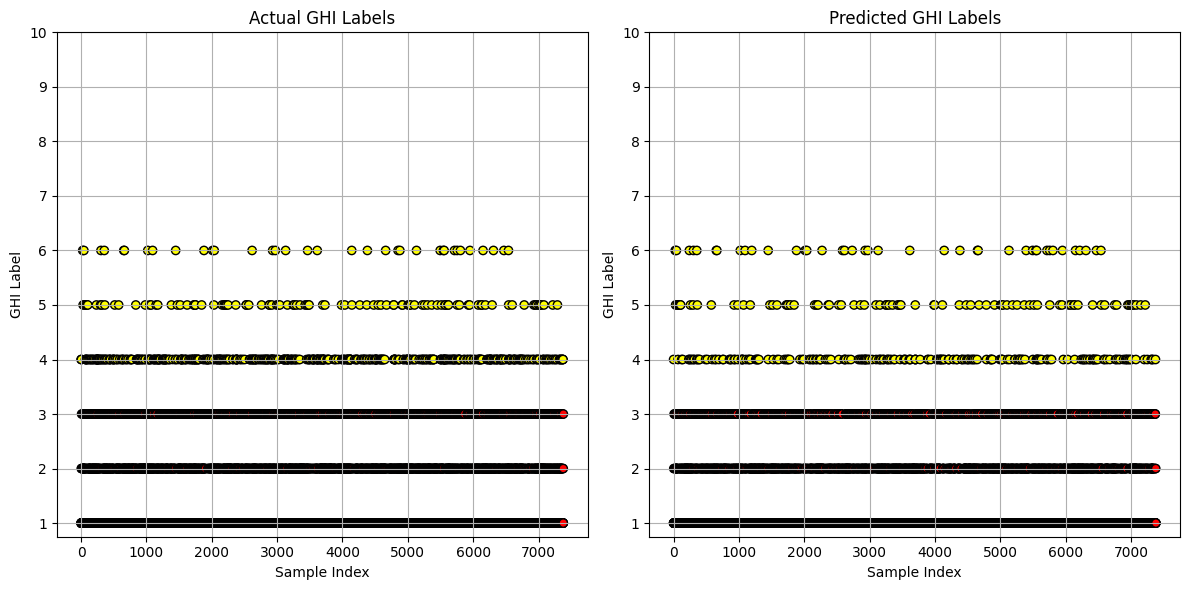

In [65]:
# Define a color map for GHI labels
def get_color(ghi_label):
    if ghi_label >= 8:
        return 'green'  # Low hunger
    elif ghi_label >= 4:
        return 'yellow'  # Moderate hunger
    else:
        return 'red'  # High hunger

# Create a scatter plot for actual vs predicted GHI labels
plt.figure(figsize=(12, 6))

# Plot actual GHI labels
plt.subplot(1, 2, 1)
colors_actual = [get_color(label) for label in y_test]
plt.scatter(range(len(y_test)), y_test, c=colors_actual, edgecolor='black')
plt.title('Actual GHI Labels')
plt.xlabel('Sample Index')
plt.ylabel('GHI Label')
plt.yticks(range(1, 11))
plt.grid(True)

# Plot predicted GHI labels
plt.subplot(1, 2, 2)
colors_pred = [get_color(label) for label in y_pred]
plt.scatter(range(len(y_pred)), y_pred, c=colors_pred, edgecolor='black')
plt.title('Predicted GHI Labels')
plt.xlabel('Sample Index')
plt.ylabel('GHI Label')
plt.yticks(range(1, 11))
plt.grid(True)

plt.tight_layout()
plt.show()